# Capstone 2 – Data Wrangling

### Dataset Overview

The dataset was previously cleaned in the Data Wrangling phase.
Below is a brief structural recap before exploration.

## Importing the libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Initial Data Assessment

In [2]:
df = pd.read_csv("../data/airline_delay_cause.csv")
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [3]:
df.shape
df.info()
print('Shape: ', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [4]:
# Check for fully duplicated rows
print("Duplicate rows:", df.duplicated().sum())

# Confirm that the total number of delayed flights across all delay categories
# does not exceed the total number of arriving flights for any row
delay_ct_cols = [
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct'
]

print("Total delay counts > total flights:",
      (df[delay_ct_cols].sum(axis=1) > df['arr_flights']).sum())

Duplicate rows: 0
Total delay counts > total flights: 8


In [5]:
# Identify rows where the total number of delayed flights (across all delay categories)
# exceeds the total number of arriving flights
row_delay_totals = df[delay_ct_cols].sum(axis=1)

# Identify rows where delay counts exceed total flights
invalid_rows = df[row_delay_totals > df['arr_flights']].copy()

# For the flagged rows, calculate how much the delay counts exceed total flights
invalid_rows['excess'] = (
    invalid_rows[delay_ct_cols]
    .sum(axis=1) 
    - invalid_rows['arr_flights']
)

# Display the excess flights
invalid_rows[['arr_flights', 'excess']].head()

,arr_flights,excess
94634,1.0,0.01
106902,1.0,0.01
107180,1.0,0.01
123293,2.0,0.01
128881,4.0,0.01


8 rows had a slight rounding difference (0.01) where total delay counts exceeded total flights. The discrepancy is negligible and does not affect the overall analysis.

The dataset is aggregated at the carrier–airport–month level, with each row representing summarized flight activity rather than individual flights. Data types were validated, missing delay values were appropriately filled with zeros where applicable, and logical consistency checks were performed. Only a small number of rows showed minor rounding discrepancies in delay counts, which were determined to be negligible and unlikely to affect analysis.

## 2. Target Variable Analysis

In [6]:
df['arr_delay'].describe()

count    317523.000000
mean       4209.989113
std       12519.021012
min           0.000000
25%         436.000000
50%        1201.000000
75%        3080.000000
max      433687.000000
Name: arr_delay, dtype: float64

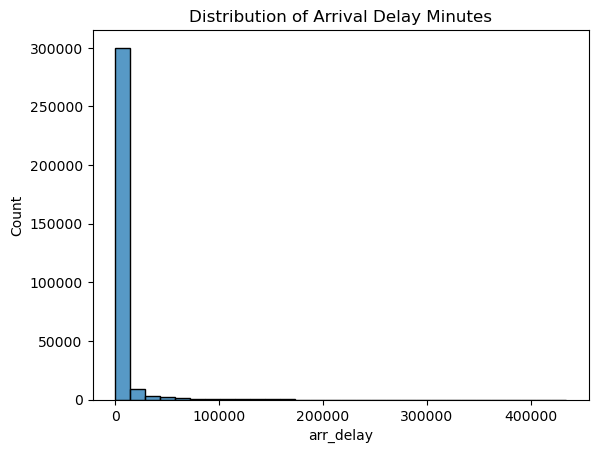

In [7]:
sns.histplot(df['arr_delay'], bins=30)
plt.title("Distribution of Arrival Delay Minutes")
plt.show()

In [8]:
df[['arr_flights','arr_delay']].corr()

,arr_flights,arr_delay
arr_flights,1.000000,0.880518
arr_delay,0.880518,1.000000


Total arrival delay minutes (arr_delay) are heavily right-skewed, with a small number of carrier–airport–month combinations contributing disproportionately large delay totals. The mean exceeds the median, further confirming skewness.

A strong positive correlation (≈0.88) exists between total arrival delay minutes and total arriving flights, indicating that flight volume is a major structural driver of total delay minutes. Larger operations naturally generate more delay minutes due to scale.

## 3. Contribution of Delay Causes

In [9]:
# Define the delay minute columns that represent total delay minutes by cause
delay_min_cols = [
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]

# Examine the relationship between individual delay causes and total arrival delay minutes
(
    df[delay_min_cols + ['arr_delay']]
    .corr()['arr_delay']
    .sort_values(ascending=False)
)

arr_delay              1.000000
late_aircraft_delay    0.937804
carrier_delay          0.905581
nas_delay              0.882103
weather_delay          0.710155
security_delay         0.389422
Name: arr_delay, dtype: float64

In [10]:
# Calculate total delay minutes for each delay category across the entire dataset
df[delay_min_cols].sum().sort_values(ascending=False)

late_aircraft_delay    506796286.0
carrier_delay          408520433.0
nas_delay              349128350.0
weather_delay           70036591.0
security_delay           2290908.0
dtype: float64

In [11]:
# Compute total delay minutes across all categories
total_delay_minutes = df[delay_min_cols].sum().sum()

# Calculate percentage contribution of each delay category to total delay minutes
percent_delay = (df[delay_min_cols].sum() / total_delay_minutes * 100).sort_values(ascending=False)

print('Total delay minutes:',total_delay_minutes)
print(round(percent_delay, 2))

Total delay minutes: 1336772568.0
late_aircraft_delay    37.91
carrier_delay          30.56
nas_delay              26.12
weather_delay           5.24
security_delay          0.17
dtype: float64


Across the entire dataset, delay minutes are primarily driven by:

- Late aircraft delay (~38%)

- Carrier delay (~31%)

- NAS delay (~26%)

- Weather and security delays contribute relatively small shares.

This suggests that delay propagation and airline operational factors account for the majority of total arrival delay minutes.

## 4. Airline-Level Analysis

In [12]:
# Average total delay minutes per carrier-airport-month
df.groupby('carrier_name')['arr_delay'].mean().sort_values(ascending=False)

carrier_name
Southwest Airlines Co.          11242.021393
American Airlines Inc.           8026.986651
United Air Lines Inc.            5975.122717
JetBlue Airways                  5427.566482
Delta Air Lines Inc.             4573.353858
US Airways Inc.                  4517.774712
Continental Air Lines Inc.       4342.163265
Spirit Air Lines                 4325.828549
American Eagle Airlines Inc.     4182.537038
ExpressJet Airlines Inc.         4003.463350
AirTran Airways Corporation      3926.668871
Atlantic Coast Airlines          3913.144453
Northwest Airlines Inc.          3664.222898
Virgin America                   3433.046283
SkyWest Airlines Inc.            3325.905671
Independence Air                 3179.829851
Atlantic Southeast Airlines      2992.045316
Republic Airline                 2915.578971
Comair Inc.                      2753.774034
America West Airlines Inc.       2713.200760
PSA Airlines Inc.                2491.983661
ATA Airlines d/b/a ATA           2225.6546

In [13]:
# Total delay minutes by airline and cause
airline_delay_totals = (
    df.groupby('carrier_name')[delay_min_cols]
      .sum()
)

# Convert to percentage contribution within each airline
airline_delay_percent = (
    airline_delay_totals
    .div(airline_delay_totals.sum(axis=1), axis=0)
    * 100
)

airline_delay_percent.round(2).head()

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
carrier_name,,,,,
ATA Airlines d/b/a ATA,19.85,1.13,42.68,0.63,35.71
AirTran Airways Corporation,15.89,1.23,32.27,0.00,50.61
Alaska Airlines Inc.,32.75,2.85,26.61,0.55,37.25
Allegiant Air,34.25,6.30,16.97,0.34,42.15
Aloha Airlines Inc.,55.23,0.88,6.07,0.71,37.12


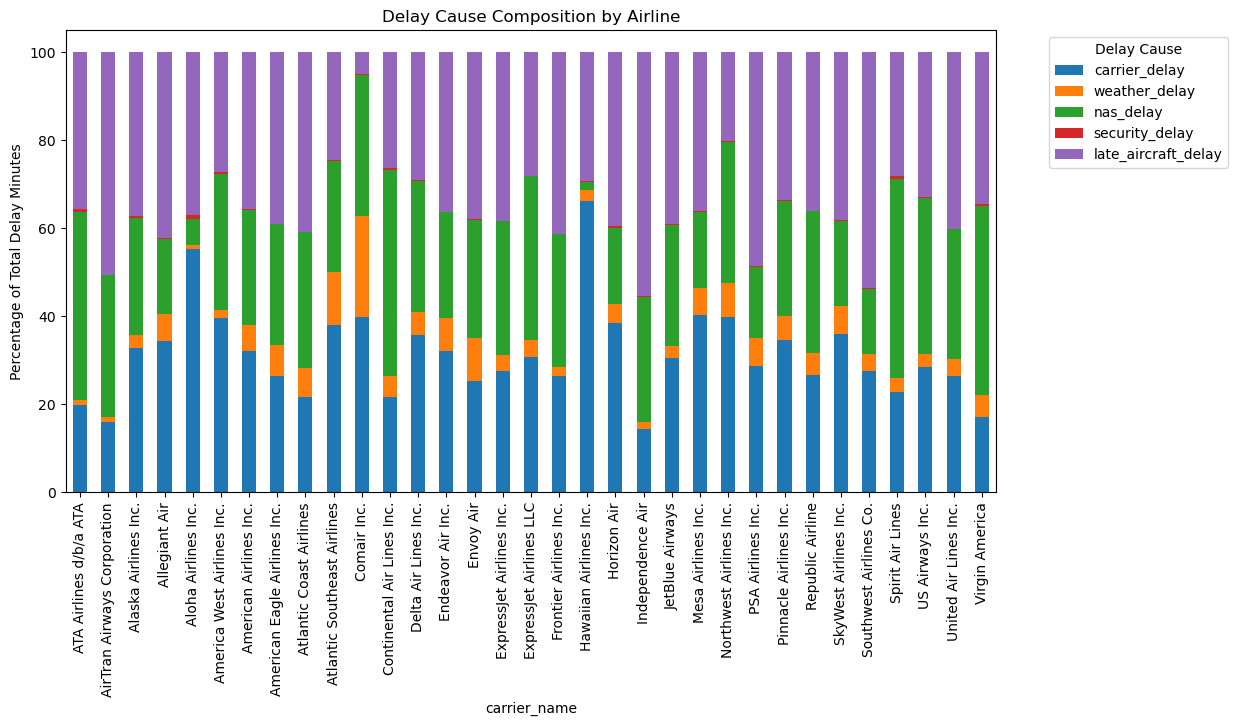

In [14]:
airline_delay_percent = airline_delay_percent.reset_index()
plot_data = airline_delay_percent.set_index('carrier_name')

plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.ylabel("Percentage of Total Delay Minutes")
plt.title("Delay Cause Composition by Airline")
plt.legend(title="Delay Cause", bbox_to_anchor=(1.05, 1))
plt.show()

The stacked bar chart shows that late aircraft delay dominates across most airlines, with relatively minor structural variation. Hawaiian carriers display higher carrier delay shares and lower NAS exposure, suggesting geographic effects.

Airline-level delay composition shows moderate structural differences, with delay propagation (late aircraft) consistently dominant. Operational and congestion-related differences exist but are not extreme.

## 5. Airport-Level Patterns

In [15]:
# Total delay minutes by airport and delay cause
airport_delay_totals = (
    df.groupby('airport_name')[delay_min_cols]
      .sum()
)

# Convert totals into percentage composition per airport
airport_delay_percent = (
    airport_delay_totals
        .div(airport_delay_totals.sum(axis=1), axis=0)
        * 100
)

# Identify top 10 airports by total delay minutes
top_airports = (
    airport_delay_totals.sum(axis=1)
        .sort_values(ascending=False)
        .head(10)
        .index
)

# Display percentage breakdown for top 10 airports
airport_delay_percent.loc[top_airports].round(2)

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
airport_name,,,,,
"Chicago, IL: Chicago O'Hare International",21.30,3.90,41.16,0.08,33.56
"Atlanta, GA: Hartsfield-Jackson Atlanta International",29.43,5.22,32.52,0.10,32.73
"Dallas/Fort Worth, TX: Dallas/Fort Worth International",29.84,6.51,23.04,0.13,40.49
"Newark, NJ: Newark Liberty International",15.12,3.52,56.67,0.09,24.60
"San Francisco, CA: San Francisco International",21.00,3.16,44.90,0.12,30.82
"Denver, CO: Denver International",31.12,4.73,23.03,0.14,40.98
"Los Angeles, CA: Los Angeles International",32.43,3.99,23.71,0.25,39.62
"Houston, TX: George Bush Intercontinental/Houston",26.89,5.55,30.75,0.17,36.64
"New York, NY: LaGuardia",20.32,5.33,49.41,0.08,24.86


While airline-level delay composition is relatively consistent, airport-level composition varies more significantly, particularly in NAS delay contributions at major congested hubs.

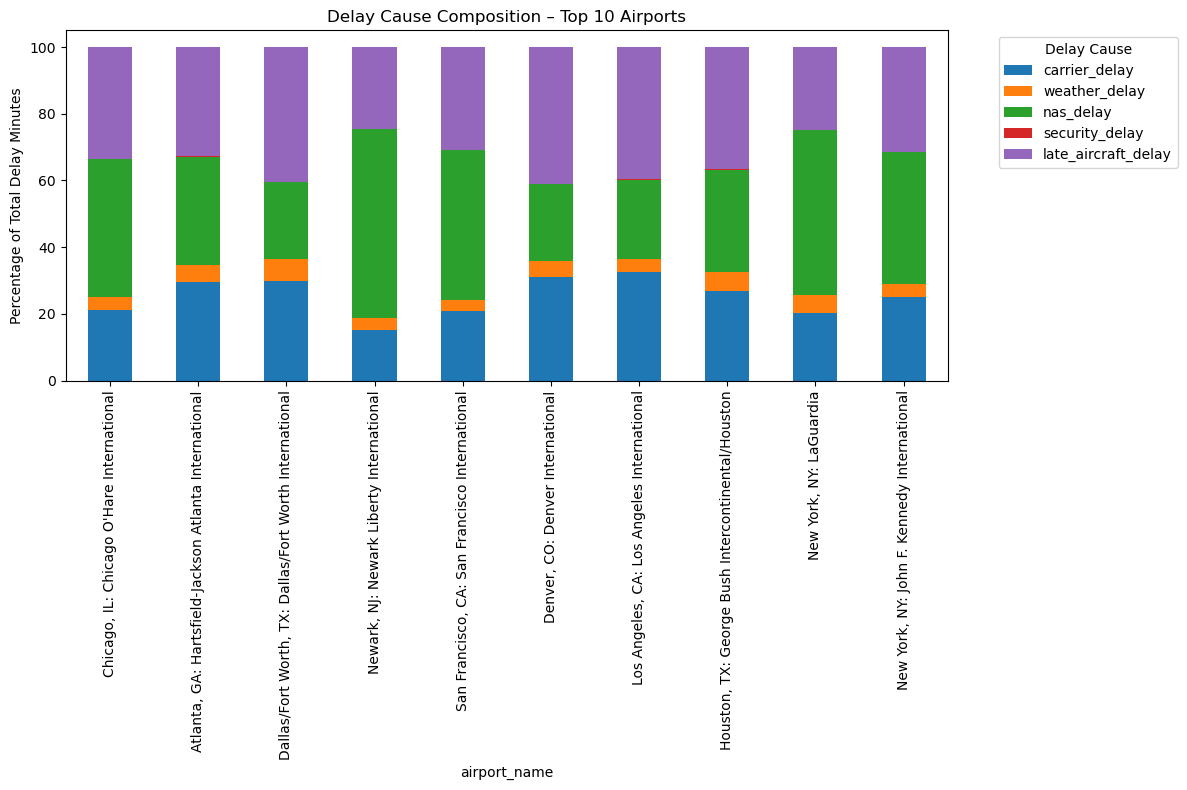

In [16]:
plot_data = (
    airport_delay_percent
        .loc[top_airports]
)

plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,8)
)

plt.ylabel("Percentage of Total Delay Minutes")
plt.title("Delay Cause Composition – Top 10 Airports")
plt.legend(title="Delay Cause", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Airport-level analysis indicates that delay composition varies more significantly across airports than across airlines, particularly in NAS delay percentages at major hubs. This suggests that congestion and airspace constraints at large airports are key structural drivers of total arrival delay minutes. Because the aviation system operates with limited buffer capacity, initial disruptions — especially congestion-related delays — propagate throughout the network, contributing to substantial late aircraft delay across both airports and airlines.

## 6. Monthly Trends

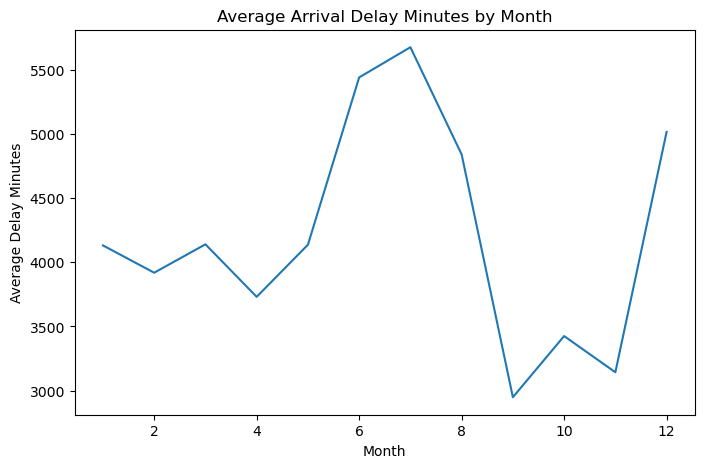

In [17]:
# Average arrival delay minutes by month
monthly_avg_delay = (
    df.groupby('month')['arr_delay']
      .mean()
)

# Plot monthly average delay
monthly_avg_delay.plot(kind='line', figsize=(8,5))

plt.title("Average Arrival Delay Minutes by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay Minutes")
plt.show()

Average arrival delay minutes show a clear seasonal pattern, with a noticeable increase during peak summer months (June–July), followed by a sharp decline in September. Delay levels begin rising again toward December, likely reflecting increased holiday travel demand and potential winter-related disruptions.

## Exploratory Data Analysis Conclusion

Exploratory analysis indicates that total arrival delay minutes are strongly associated with flight volume and delay propagation. System-level analysis shows that late aircraft, carrier, and NAS delays account for the majority of total arrival delay minutes, with late aircraft delay consistently representing the largest share.

Airline-level delay composition is relatively consistent across carriers, suggesting limited structural variation driven by airline-specific operational differences. In contrast, airport-level composition shows greater variability, particularly in NAS delay percentages at major congested hubs. This indicates that infrastructure constraints and airspace congestion play a significant structural role in total delay minutes.

Seasonal analysis reveals predictable increases in delay magnitude during peak summer travel and winter holiday periods, although the overall composition of delay causes remains broadly stable throughout the year.

Overall, these findings suggest that both congestion-related factors and delay propagation are central drivers of arrival delay minutes.